# ResNet-18 PCA variance and physical alignment

This notebook analyzes the **raw, non-inverted** frozen ResNet-18 embeddings. No global spin symmetry is imposed before the network.

It answers four questions:

1. How is explained variance distributed across principal components?
2. How many PCs are needed to capture 90% of the embedding variance?
3. How stable are the leading explained-variance ratios across independent seed resamples?
4. Which physical observables align with each retained PC, and in which direction?

The bootstrap box plot resamples simulation seeds, rather than individual correlated bins.

In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

L = 16
N_SITES = L ** 2
N_RUNS = 1_000
N_TEMPERATURES = 31
BINS_PER_TEMPERATURE = 10
N_CONFIGURATIONS = N_RUNS * N_TEMPERATURES * BINS_PER_TEMPERATURE

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / "data" / "raw").exists())
DATA_ROOT = REPO_ROOT / "data" / "raw"
OUTPUT_ROOT = REPO_ROOT / "data" / "processed"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

EMBEDDING_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_embeddings.npy"
TEMPERATURE_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_temperatures.npy"
MAGNETIZATION_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_signed_magnetization.npy"

assert EMBEDDING_PATH.exists(), "Run ising16_magnetization.ipynb first to create raw ResNet embeddings."
embeddings = np.load(EMBEDDING_PATH, mmap_mode="r")
embedding_temperatures = np.load(TEMPERATURE_PATH)
assert embeddings.shape == (N_CONFIGURATIONS, 512)

run_dirs = sorted(
    DATA_ROOT.glob("ising16_tc_[0-9]*"),
    key=lambda path: int(path.name.rsplit("_", 1)[1]),
)
assert len(run_dirs) == N_RUNS

temperature_grid = embedding_temperatures.reshape(
    N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE
)
temperatures = temperature_grid[0, :, 0]
assert np.all(temperature_grid == temperatures[None, :, None])

print(f"Embeddings: {embeddings.shape}")
print(f"Temperatures: {temperatures[0]:g} to {temperatures[-1]:g}")

Embeddings: (310000, 512)
Temperatures: 1.5 to 3


## Magnetization calculated directly from spins

Signed magnetization is recomputed as $m=\sum_i s_i/L^2$ and cached for later notebooks.

In [2]:
if MAGNETIZATION_PATH.exists():
    signed_magnetization = np.load(MAGNETIZATION_PATH)
else:
    signed_magnetization = np.empty(N_CONFIGURATIONS, dtype=np.float32)
    offset = 0
    for run_index, run_dir in enumerate(run_dirs):
        suffix = run_dir.name
        spins = np.loadtxt(
            run_dir / f"spinConfigs_{suffix}.txt", dtype=np.int8
        )
        count = len(spins)
        signed_magnetization[offset:offset + count] = (
            spins.sum(axis=1, dtype=np.int32) / N_SITES
        )
        offset += count
        if (run_index + 1) % 200 == 0:
            print(f"Read {run_index + 1:,}/{N_RUNS:,} runs")
    assert offset == N_CONFIGURATIONS
    np.save(MAGNETIZATION_PATH, signed_magnetization)

abs_magnetization = np.abs(signed_magnetization)
print(f"Magnetization cache: {signed_magnetization.shape}")

Magnetization cache: (310000,)


## Exact covariance eigendecomposition

The 512×512 covariance is accumulated in GPU-friendly batches and diagonalized exactly. This avoids guessing a component cutoff with a truncated PCA solver.

In [3]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COVARIANCE_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_covariance.npz"

if COVARIANCE_PATH.exists():
    covariance_cache = np.load(COVARIANCE_PATH)
    feature_mean = covariance_cache["feature_mean"]
    eigenvalues = covariance_cache["eigenvalues"]
    components = covariance_cache["components"]
else:
    feature_sum = torch.zeros(512, dtype=torch.float64, device=DEVICE)
    second_moment = torch.zeros((512, 512), dtype=torch.float64, device=DEVICE)
    batch_size = 8_192

    for start in range(0, N_CONFIGURATIONS, batch_size):
        stop = min(start + batch_size, N_CONFIGURATIONS)
        batch = torch.from_numpy(np.asarray(embeddings[start:stop])).to(
            DEVICE, dtype=torch.float64
        )
        feature_sum += batch.sum(dim=0)
        second_moment += batch.T @ batch

    feature_mean_tensor = feature_sum / N_CONFIGURATIONS
    covariance = (
        second_moment - N_CONFIGURATIONS * torch.outer(feature_mean_tensor, feature_mean_tensor)
    ) / (N_CONFIGURATIONS - 1)
    eigenvalues_tensor, eigenvectors_tensor = torch.linalg.eigh(covariance)
    order = torch.argsort(eigenvalues_tensor, descending=True)

    eigenvalues = eigenvalues_tensor[order].cpu().numpy()
    components = eigenvectors_tensor[:, order].T.cpu().numpy()
    feature_mean = feature_mean_tensor.cpu().numpy()
    np.savez(
        COVARIANCE_PATH,
        feature_mean=feature_mean,
        eigenvalues=eigenvalues,
        components=components,
    )

explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components_90 = int(np.searchsorted(cumulative_variance, 0.90) + 1)

print(f"Device: {DEVICE}")
print(f"PCs required for 90% variance: {n_components_90}")
print(f"Variance retained: {cumulative_variance[n_components_90 - 1]:.3%}")

Device: cuda
PCs required for 90% variance: 22
Variance retained: 90.055%


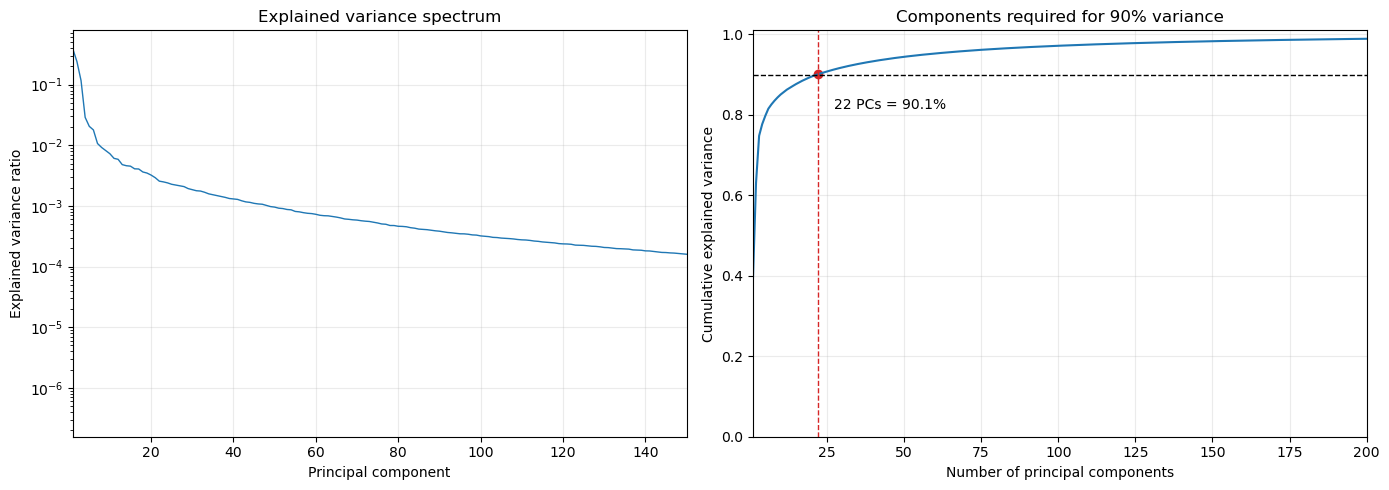

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pc_numbers = np.arange(1, len(explained_variance_ratio) + 1)

axes[0].plot(pc_numbers, explained_variance_ratio, linewidth=1)
axes[0].set(
    xlabel="Principal component",
    ylabel="Explained variance ratio",
    title="Explained variance spectrum",
    xlim=(1, min(150, len(pc_numbers))),
)
axes[0].set_yscale("log")
axes[0].grid(alpha=0.25)

axes[1].plot(pc_numbers, cumulative_variance, linewidth=1.5)
axes[1].axhline(0.90, color="black", linestyle="--", linewidth=1)
axes[1].axvline(n_components_90, color="tab:red", linestyle="--", linewidth=1)
axes[1].scatter([n_components_90], [cumulative_variance[n_components_90 - 1]], color="tab:red")
axes[1].annotate(
    f"{n_components_90} PCs = {cumulative_variance[n_components_90 - 1]:.1%}",
    (n_components_90, cumulative_variance[n_components_90 - 1]),
    xytext=(12, -25),
    textcoords="offset points",
)
axes[1].set(
    xlabel="Number of principal components",
    ylabel="Cumulative explained variance",
    title="Components required for 90% variance",
    xlim=(1, min(200, len(pc_numbers))),
    ylim=(0, 1.01),
)
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_variance_spectrum.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

## Seed-bootstrap explained-variance box plot

Each bootstrap replicate samples 100 independent seeds with replacement, retains all ten configurations per seed-temperature pair, and recomputes its covariance spectrum. Boxes therefore reflect variation across independent simulation ensembles.

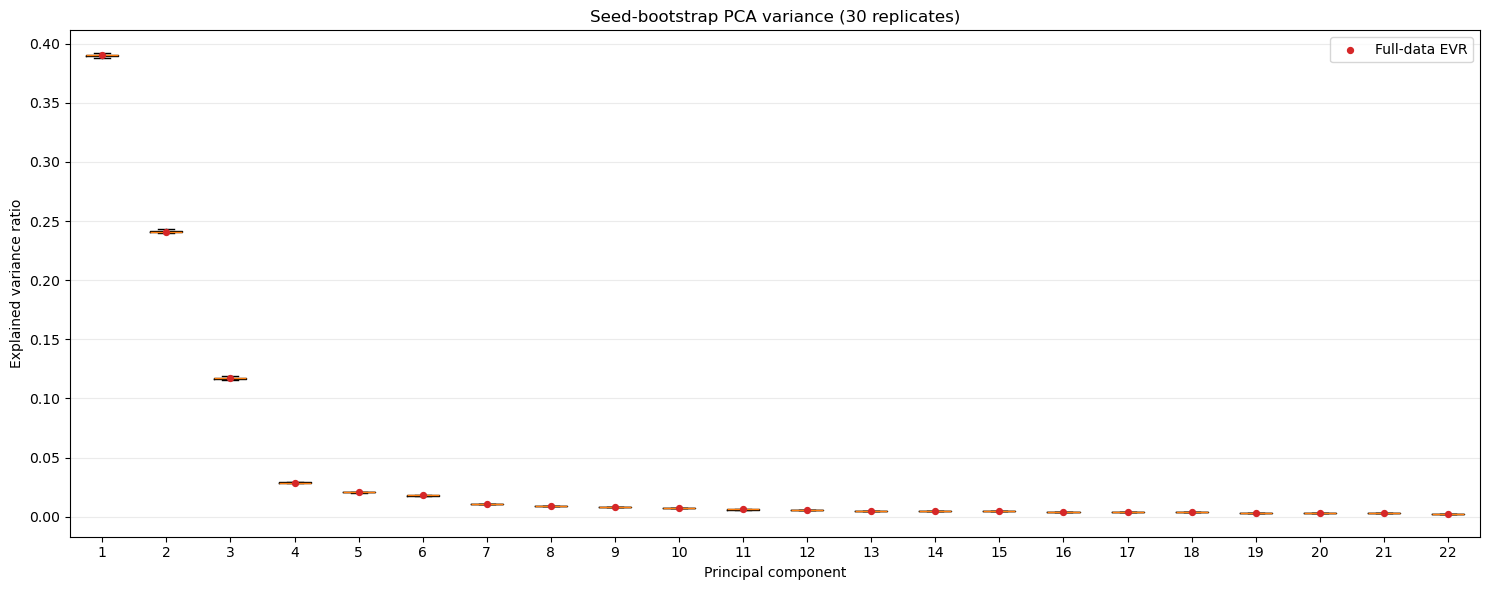

In [5]:
BOOTSTRAP_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca_bootstrap_evr.npy"
N_BOOTSTRAPS = 30
SEEDS_PER_BOOTSTRAP = 100
BOX_COMPONENTS = min(30, n_components_90)

embedding_grid = np.asarray(embeddings).reshape(
    N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE, 512
)

if BOOTSTRAP_PATH.exists():
    bootstrap_evr = np.load(BOOTSTRAP_PATH)
else:
    rng = np.random.default_rng(42)
    bootstrap_evr = np.empty((N_BOOTSTRAPS, BOX_COMPONENTS), dtype=np.float64)
    for bootstrap_index in range(N_BOOTSTRAPS):
        sampled_seeds = rng.integers(0, N_RUNS, size=SEEDS_PER_BOOTSTRAP)
        sample = embedding_grid[sampled_seeds].reshape(-1, 512)
        centered = sample - sample.mean(axis=0, keepdims=True)
        sample_covariance = centered.T @ centered / (len(sample) - 1)
        sample_eigenvalues = np.linalg.eigvalsh(sample_covariance)[::-1]
        bootstrap_evr[bootstrap_index] = (
            sample_eigenvalues[:BOX_COMPONENTS] / sample_eigenvalues.sum()
        )
    np.save(BOOTSTRAP_PATH, bootstrap_evr)

fig, ax = plt.subplots(figsize=(15, 6))
ax.boxplot(
    [bootstrap_evr[:, index] for index in range(BOX_COMPONENTS)],
    positions=np.arange(1, BOX_COMPONENTS + 1),
    showfliers=False,
)
ax.scatter(
    np.arange(1, BOX_COMPONENTS + 1),
    explained_variance_ratio[:BOX_COMPONENTS],
    color="tab:red",
    s=18,
    label="Full-data EVR",
    zorder=3,
)
ax.set(
    xlabel="Principal component",
    ylabel="Explained variance ratio",
    title=f"Seed-bootstrap PCA variance ({N_BOOTSTRAPS} replicates)",
)
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_pca_variance_boxplot.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

## PC alignment directions

“Alignment” is defined here as Pearson correlation between each PC score and three held-out physical descriptors: temperature, signed magnetization, and absolute magnetization. These quantities are **not** used to fit PCA. The sign gives the direction of alignment, while magnitude gives its strength.

Because a PCA eigenvector's sign is arbitrary, interpretation should focus on consistent relative signs and absolute strengths rather than treating “positive PC” as intrinsically meaningful.

In [6]:
SCORES_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca90_scores.npy"
PCA_METADATA_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca90_metadata.json"

if SCORES_PATH.exists():
    pca90_scores = np.load(SCORES_PATH, mmap_mode="r")
else:
    pca90_scores = np.lib.format.open_memmap(
        SCORES_PATH,
        mode="w+",
        dtype=np.float32,
        shape=(N_CONFIGURATIONS, n_components_90),
    )
    for start in range(0, N_CONFIGURATIONS, 8_192):
        stop = min(start + 8_192, N_CONFIGURATIONS)
        centered = np.asarray(embeddings[start:stop]) - feature_mean
        pca90_scores[start:stop] = centered @ components[:n_components_90].T
    pca90_scores.flush()

with open(PCA_METADATA_PATH, "w") as handle:
    json.dump(
        {
            "n_components_90": n_components_90,
            "variance_retained": float(cumulative_variance[n_components_90 - 1]),
            "n_configurations": N_CONFIGURATIONS,
            "embedding_dimension": 512,
            "spin_inversion_used": False,
        },
        handle,
        indent=2,
    )

observables = {
    "temperature": embedding_temperatures,
    "signed_magnetization": signed_magnetization,
    "absolute_magnetization": abs_magnetization,
}
alignment = np.empty((len(observables), n_components_90), dtype=np.float64)

for row, values in enumerate(observables.values()):
    values_centered = values - values.mean()
    values_scale = np.sqrt(np.sum(values_centered ** 2))
    for pc_index in range(n_components_90):
        scores = np.asarray(pca90_scores[:, pc_index])
        scores_centered = scores - scores.mean()
        alignment[row, pc_index] = np.dot(scores_centered, values_centered) / (
            np.sqrt(np.sum(scores_centered ** 2)) * values_scale
        )

alignment_table = pd.DataFrame(
    alignment.T,
    columns=list(observables),
    index=np.arange(1, n_components_90 + 1),
)
alignment_table.index.name = "principal_component"
alignment_table.to_csv(OUTPUT_ROOT / "ising16_resnet18_raw_pc_alignment.csv")

display(alignment_table)
for observable in alignment_table.columns:
    strongest_pc = alignment_table[observable].abs().idxmax()
    print(
        f"Strongest {observable} alignment: PC{strongest_pc} "
        f"(r={alignment_table.loc[strongest_pc, observable]:+.3f})"
    )

,temperature,signed_magnetization,absolute_magnetization
principal_component,,,
1,-0.842309,-0.056514,0.855018
2,-0.000367,0.895366,0.098100
3,-0.085563,0.369491,-0.197702
4,-0.040167,-0.038189,0.104370
5,-0.130894,0.140546,0.258845
6,-0.020728,0.022637,0.086937
7,-0.120012,-0.096399,0.093803
8,-0.002513,0.034207,0.012348
9,0.121153,-0.004615,0.005297


Strongest temperature alignment: PC1 (r=-0.842)
Strongest signed_magnetization alignment: PC2 (r=+0.895)
Strongest absolute_magnetization alignment: PC1 (r=+0.855)


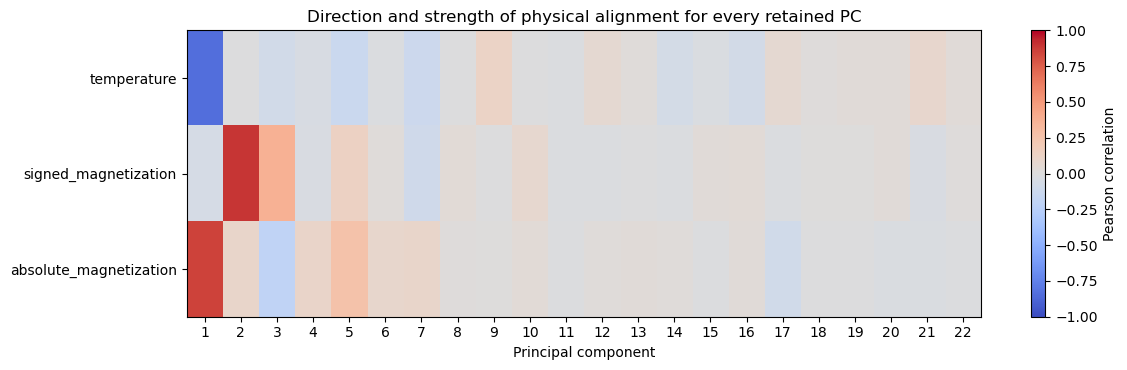

In [7]:
fig, ax = plt.subplots(figsize=(max(12, n_components_90 * 0.28), 3.8))
image = ax.imshow(alignment, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_yticks(np.arange(len(observables)), labels=list(observables))
ax.set_xticks(np.arange(n_components_90), labels=np.arange(1, n_components_90 + 1))
ax.set(
    xlabel="Principal component",
    title="Direction and strength of physical alignment for every retained PC",
)
if n_components_90 > 45:
    for label_index, label in enumerate(ax.get_xticklabels()):
        label.set_visible(label_index % 2 == 0)
fig.colorbar(image, ax=ax, label="Pearson correlation")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_pc_alignment.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)